This notebook reproduces Figure S1 in "Humidity’s role in population heat-health risk" by Kong et al.

In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.stats import pearsonr

/tmp/ipykernel_1127366/1756009576.py:8: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [2]:
# read in mean absolute prediction error of GHSI
mae=xr.open_dataset('../data/GHSI_MAE.nc').MAE
"""
MAE of daily heatstroke prediction at each prefecture (dim: pf);
Conditional on a wide range of humidity weight (dim: beta);
For both outdoor and indoor versions (dim: exposure) of General Heat Stress Index (GHSI);
MAE is calculated as an average across the validation periods of 10-fold cross validation
"""
mae

<xarray.DataArray 'MAE' (pf: 47, exposure: 2, beta: 2451)> Size: 2MB
[230394 values with dtype=float64]
Coordinates:
  * pf        (pf) int64 376B 1 2 3 4 5 6 7 8 9 ... 39 40 41 42 43 44 45 46 47
  * exposure  (exposure) <U7 56B 'outdoor' 'indoor'
  * beta      (beta) float64 20kB -8.0 -7.99 -7.98 -7.97 ... 16.48 16.49 16.5
Attributes:
    long_name:  Mean absolute error (MAE) of daily heatstroke prediction at e...

In [3]:
# determine optimal humidity weight (beta) with lowest MAE for each prefecture
optimal_beta=mae.idxmin(dim='beta')

In [4]:
# read in summer (June-Sep) average temperature at the capital city of each prefecture during 2010-2019
Ta=xr.open_dataset('../data/Prefecture_summer_average_temp.nc').Ta


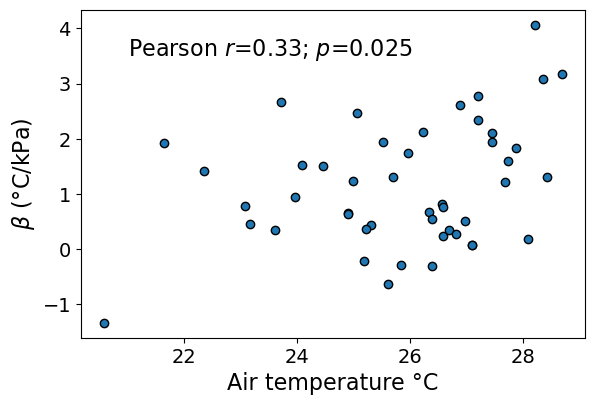

In [5]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(1,1,1)  
ax.scatter(Ta-273.15,optimal_beta.sel(exposure='outdoor'),edgecolors='k',linewidth=1)
ax.set_xlabel('Air temperature °C',fontsize=16)
ax.set_ylabel(r'$\beta$ (°C/kPa)',fontsize=16)
ax.tick_params(axis='both', labelsize=14)
r,p=pearsonr((Ta-273.15).values,optimal_beta.sel(exposure='outdoor').values) #calculate pearson correlation and p-value
ax.text(21,3.5,r'Pearson $r$='+f"{r:.2f}; "+r'$p$='+f"{p:.3f}",fontsize=16)

fig.subplots_adjust(bottom=0.15, left=0.13, right=0.97, top=0.97)

out_dir = '/home/kong97/coding/optimal_metric/Japan/revision/plot/publication_data_share'
fig.savefig(f'{out_dir}/FigureA1_v2.pdf', bbox_inches=None)

**Fig. S1.** Scatterplot of optimal $\beta$ for the outdoor formulation of GHSI against summer-mean air temperature across prefectures. Pearson correlation $r$ and the $p$-value are shown on the panel. Removing Hokkaido (the lower-leftmost point) lowers the correlation to $r=0.22$ with $p=0.15$.